In [11]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.colors  as mcolors
import shap

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (precision_score, recall_score, f1_score,
                                     confusion_matrix, ConfusionMatrixDisplay)

SEED     = 42
DATA_DIR = '../data/'

FEATURES = ['PNA','is_foreign','estuvo.prepa_tec','first.generation.yes',
            'has_extracurriculars','parents_exatec_enc','total.scholarship.loan','FTE']

FEAT_LABELS = {
    'PNA':                   'PNA',
    'is_foreign':            'Extranjero',
    'estuvo.prepa_tec':      'Prepa Tec',
    'first.generation.yes':  '1ra Generación',
    'has_extracurriculars':  'Extracurriculares',
    'parents_exatec_enc':    'Padres Exatec',
    'total.scholarship.loan':'Beca/Préstamo',
    'FTE':                   'FTE',
}

PAL = ['#16a34a','#22c55e','#3b82f6','#f59e0b','#f97316','#ef4444']

print("Librerías cargadas ✓")
print(f"SHAP version: {shap.__version__}")

Librerías cargadas ✓
SHAP version: 0.49.1


In [12]:
pre_df = pd.read_csv(DATA_DIR + 'v5_dataset_pre_tec21_clusters.csv')
tec_df = pd.read_csv(DATA_DIR + 'v5_dataset_tec21_clusters.csv')

for df in [pre_df, tec_df]:
    if 'is_foreign' not in df.columns:
        df['is_foreign'] = df['foreign_Yes: Foreigner'].astype(int)
    if 'dropout' not in df.columns:
        df['dropout'] = 1 - df['retention']

print(f"Pre-TEC21 : {pre_df.shape[0]:,} filas | {sorted(pre_df.cluster_label.unique())}")
print(f"TEC21     : {tec_df.shape[0]:,} filas | {sorted(tec_df.cluster_label.unique())}")

Pre-TEC21 : 53,010 filas | ['C0_prepa_sin_beca', 'C1_alto_pna_beca', 'C2_primera_gen_extracurr', 'C3_pna_bajo_sin_beca', 'C4_extranjeros', 'C5_sin_extracurriculares']
TEC21     : 24,507 filas | ['C0_alto_pna_beca', 'C1_pna_bajo_sin_beca', 'C2_sin_extracurriculares', 'C3_extranjeros', 'C4_primera_gen', 'C5_perfil_vulnerable']


---
## 📐 ¿Qué mide cada métrica?

### Precision (Precisión)
> **"De los que el modelo predijo como desertores, ¿qué fracción realmente desertó?"**

`Precision = TP / (TP + FP)`

- **Alta** → pocas falsas alarmas; intervenciones dirigidas y eficientes.
- **Baja** → el modelo etiqueta como desertor a muchos que en realidad se quedaron.

---

### Recall (Sensibilidad)
> **"De todos los que realmente desertaron, ¿qué fracción detectó el modelo?"**

`Recall = TP / (TP + FN)`

- **Alto** → captura la mayoría de los desertores reales; pocos se escapan sin detectar.
- **Bajo** → muchos desertores pasan desapercibidos (falsos negativos).

---

### F1-Score
> **Media armónica entre Precision y Recall. Equilibra ambas métricas.**

`F1 = 2 · (Precision · Recall) / (Precision + Recall)`

Útil con clases desbalanceadas (como deserción, donde los que salen son minoría).
`F1 = 1.0` es perfecto; `F1 = 0.0` es inútil.

---

### SHAP Values
> **"¿Cuánto empujó cada variable la predicción hacia deserción para cada estudiante?"**

Basados en teoría de juegos cooperativos.
- **Valor positivo** → esa variable empuja la predicción hacia **deserción**.
- **Valor negativo** → esa variable empuja hacia **retención**.
- `mean(|SHAP|)` → importancia global de la variable dentro del cluster.
- Los beeswarms muestran tanto la magnitud como la dirección del efecto.

In [13]:
def train_rf_cluster(sub_df, feat_cols=FEATURES, seed=SEED):
    """Entrena RF en el subgrupo, devuelve (model, X_te, y_te, shap_2d, metrics, valid_feats)."""
    valid = [f for f in feat_cols if sub_df[f].std() > 0]
    X = sub_df[valid].values.astype(float)
    y = sub_df['dropout'].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)

    rf = RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        class_weight='balanced', random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)

    metrics = {
        'n':          len(X),
        'dropout_rate': y.mean(),
        'precision':  precision_score(y_te, y_pred, zero_division=0),
        'recall':     recall_score   (y_te, y_pred, zero_division=0),
        'f1':         f1_score       (y_te, y_pred, zero_division=0),
    }

    # SHAP — manejo de array 3D (nueva API) y lista (API antigua)
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(X_te)
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        shap_2d = sv[:, :, 1]          # (n_test, n_feats) para clase deserción
    elif isinstance(sv, list):
        shap_2d = sv[1]
    else:
        shap_2d = sv

    return rf, X_te, y_te, shap_2d, metrics, valid


def custom_beeswarm(ax, shap_2d, X_te, feat_names, title, rng=None):
    """Dibuja beeswarm de SHAP manualmente en el eje dado."""
    if rng is None:
        rng = np.random.default_rng(42)
    n_feats = shap_2d.shape[1]
    # Ordenar features por importancia media
    order = np.argsort(np.abs(shap_2d).mean(axis=0))   # menor a mayor
    cmap  = plt.cm.RdBu_r

    for rank, fi in enumerate(order):
        sv_col  = shap_2d[:, fi]
        feat_col = X_te[:, fi]
        # Normalizar colores por percentil
        vmin, vmax = np.percentile(feat_col, [5, 95])
        if vmax > vmin:
            norm_val = np.clip((feat_col - vmin) / (vmax - vmin), 0, 1)
        else:
            norm_val = np.full_like(feat_col, 0.5)
        colors = cmap(norm_val)
        # Jitter vertical
        jitter = rng.uniform(-0.2, 0.2, size=len(sv_col))
        ax.scatter(sv_col, np.full_like(sv_col, rank) + jitter,
                   c=colors, s=6, alpha=0.5, linewidths=0)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(n_feats))
    ax.set_yticklabels([feat_names[i] for i in order], fontsize=8)
    ax.set_xlabel('SHAP value', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)


print("Funciones definidas ✓")

Funciones definidas ✓


---
## 🟩 Pre-TEC21 — Random Forest por Cluster

In [14]:
clusters_pre = sorted(pre_df.cluster_label.unique())
results_pre  = []
models_pre   = {}

for cl in clusters_pre:
    sub = pre_df[pre_df.cluster_label == cl].copy()
    rf, X_te, y_te, shap_2d, metrics, valid = train_rf_cluster(sub)
    results_pre.append({'cluster': cl, **metrics})
    models_pre[cl] = dict(rf=rf, X_te=X_te, y_te=y_te,
                          shap=shap_2d, feats=valid)
    print(f"  ✓ {cl:<38} | n={metrics['n']:>6,} "
          f"| dropout={metrics['dropout_rate']:.1%} "
          f"| P={metrics['precision']:.3f} R={metrics['recall']:.3f} F1={metrics['f1']:.3f}")

metrics_pre = pd.DataFrame(results_pre).set_index('cluster')

  ✓ C0_prepa_sin_beca                      | n= 5,695 | dropout=4.8% | P=0.082 R=0.564 F1=0.143
  ✓ C1_alto_pna_beca                       | n=18,221 | dropout=6.1% | P=0.086 R=0.426 F1=0.144
  ✓ C2_primera_gen_extracurr               | n= 2,521 | dropout=10.6% | P=0.135 R=0.453 F1=0.208
  ✓ C3_pna_bajo_sin_beca                   | n=24,505 | dropout=11.1% | P=0.140 R=0.613 F1=0.228
  ✓ C4_extranjeros                         | n= 1,667 | dropout=14.2% | P=0.147 R=0.489 F1=0.227
  ✓ C5_sin_extracurriculares               | n=   401 | dropout=20.2% | P=0.154 R=0.250 F1=0.190


---
## 🟦 TEC21 — Random Forest por Cluster

In [15]:
clusters_tec = sorted(tec_df.cluster_label.unique())
results_tec  = []
models_tec   = {}

for cl in clusters_tec:
    sub = tec_df[tec_df.cluster_label == cl].copy()
    rf, X_te, y_te, shap_2d, metrics, valid = train_rf_cluster(sub)
    results_tec.append({'cluster': cl, **metrics})
    models_tec[cl] = dict(rf=rf, X_te=X_te, y_te=y_te,
                          shap=shap_2d, feats=valid)
    print(f"  ✓ {cl:<38} | n={metrics['n']:>6,} "
          f"| dropout={metrics['dropout_rate']:.1%} "
          f"| P={metrics['precision']:.3f} R={metrics['recall']:.3f} F1={metrics['f1']:.3f}")

metrics_tec = pd.DataFrame(results_tec).set_index('cluster')

  ✓ C0_alto_pna_beca                       | n= 7,510 | dropout=4.3% | P=0.046 R=0.231 F1=0.076
  ✓ C1_pna_bajo_sin_beca                   | n= 8,337 | dropout=9.3% | P=0.137 R=0.503 F1=0.215
  ✓ C2_sin_extracurriculares               | n= 3,997 | dropout=10.5% | P=0.121 R=0.464 F1=0.192
  ✓ C3_extranjeros                         | n=   938 | dropout=10.7% | P=0.094 R=0.250 F1=0.137
  ✓ C4_primera_gen                         | n= 2,894 | dropout=12.1% | P=0.187 R=0.629 F1=0.289
  ✓ C5_perfil_vulnerable                   | n=   831 | dropout=19.3% | P=0.295 R=0.562 F1=0.387


---
## 📊 Comparación de Métricas

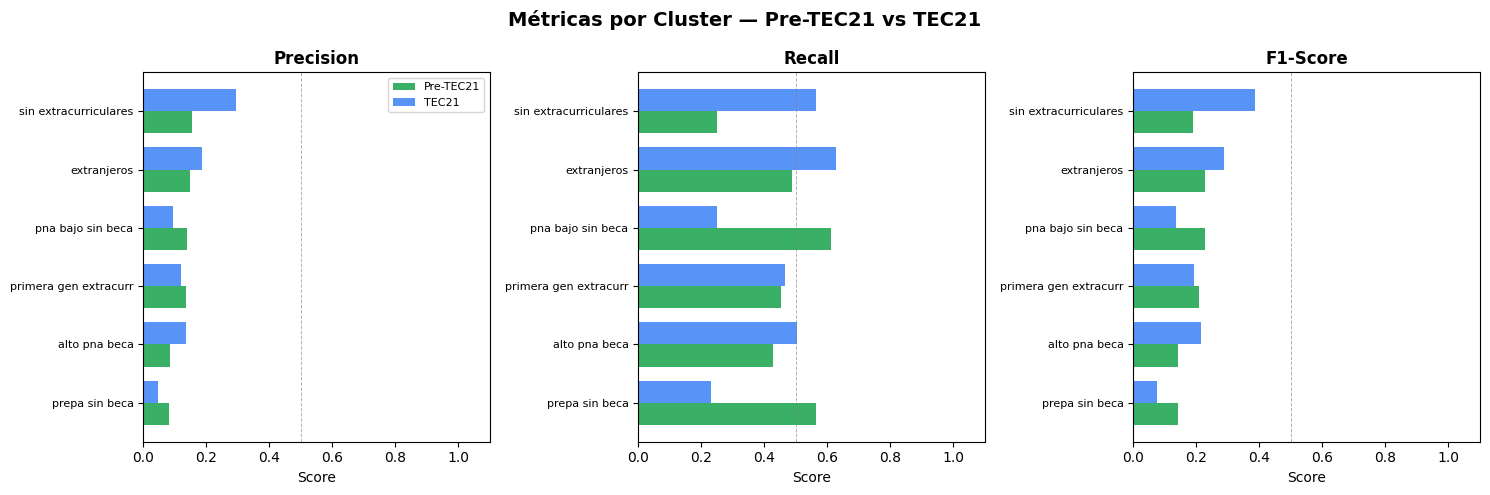

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Métricas por Cluster — Pre-TEC21 vs TEC21', fontsize=14, fontweight='bold')

metric_cols   = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1-Score']

for ax, col, label in zip(axes, metric_cols, metric_labels):
    pre_vals = metrics_pre[col].values
    tec_vals = metrics_tec[col].values
    pre_labs = [c.split('_',1)[1].replace('_',' ') for c in metrics_pre.index]
    tec_labs = [c.split('_',1)[1].replace('_',' ') for c in metrics_tec.index]
    n = max(len(pre_labs), len(tec_labs))

    bar_h = 0.38
    y_pre = np.arange(len(pre_vals))
    y_tec = np.arange(len(tec_vals)) + bar_h

    ax.barh(y_pre, pre_vals, height=bar_h, color='#16a34a', alpha=0.85, label='Pre-TEC21')
    ax.barh(y_tec, tec_vals, height=bar_h, color='#3b82f6', alpha=0.85, label='TEC21')
    ax.set_yticks(y_pre + bar_h/2)
    ax.set_yticklabels(pre_labs, fontsize=8)
    ax.set_xlim(0, 1.1)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')
    if col == 'precision':
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔢 Matrices de Confusión — Pre-TEC21

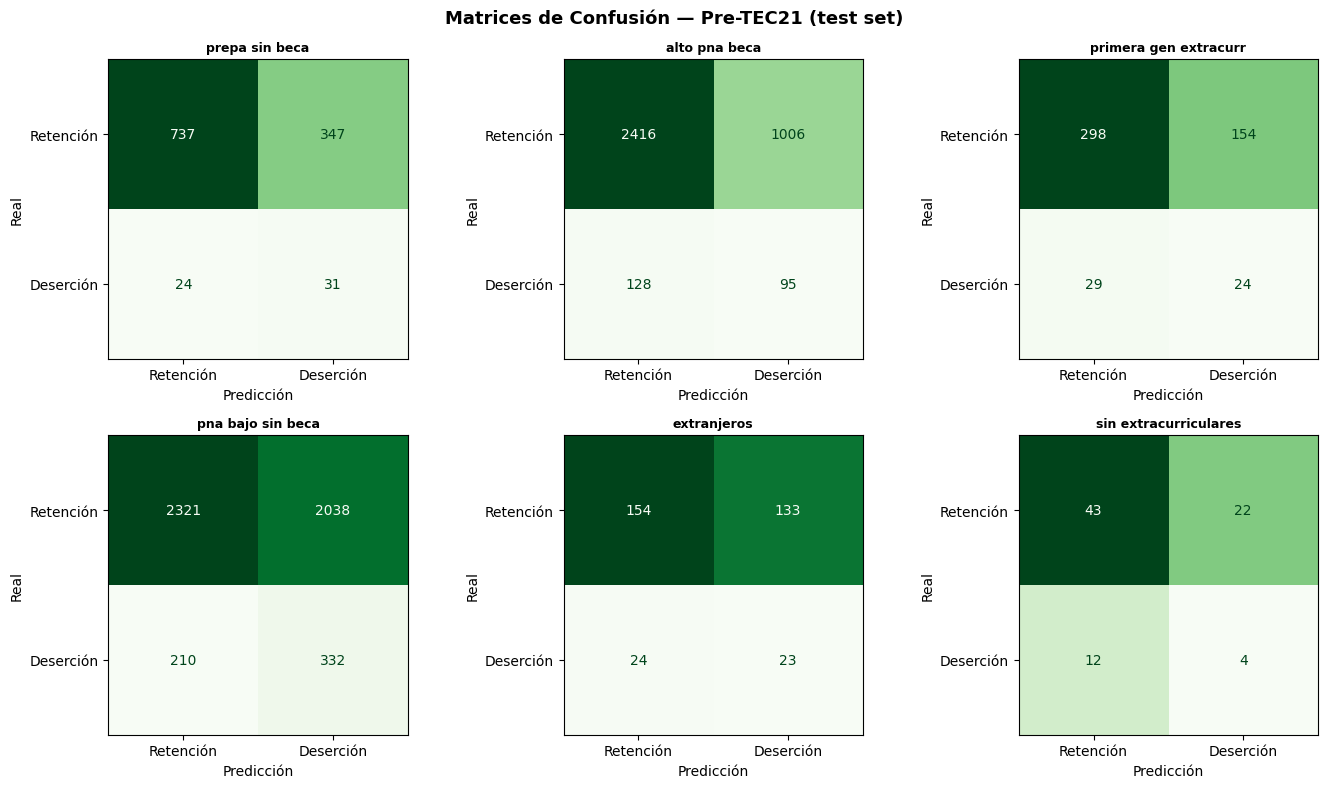

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — Pre-TEC21 (test set)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    m = models_pre[cl]
    y_pred = m['rf'].predict(m['X_te'])
    cm = confusion_matrix(m['y_te'], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

---
## 🔢 Matrices de Confusión — TEC21

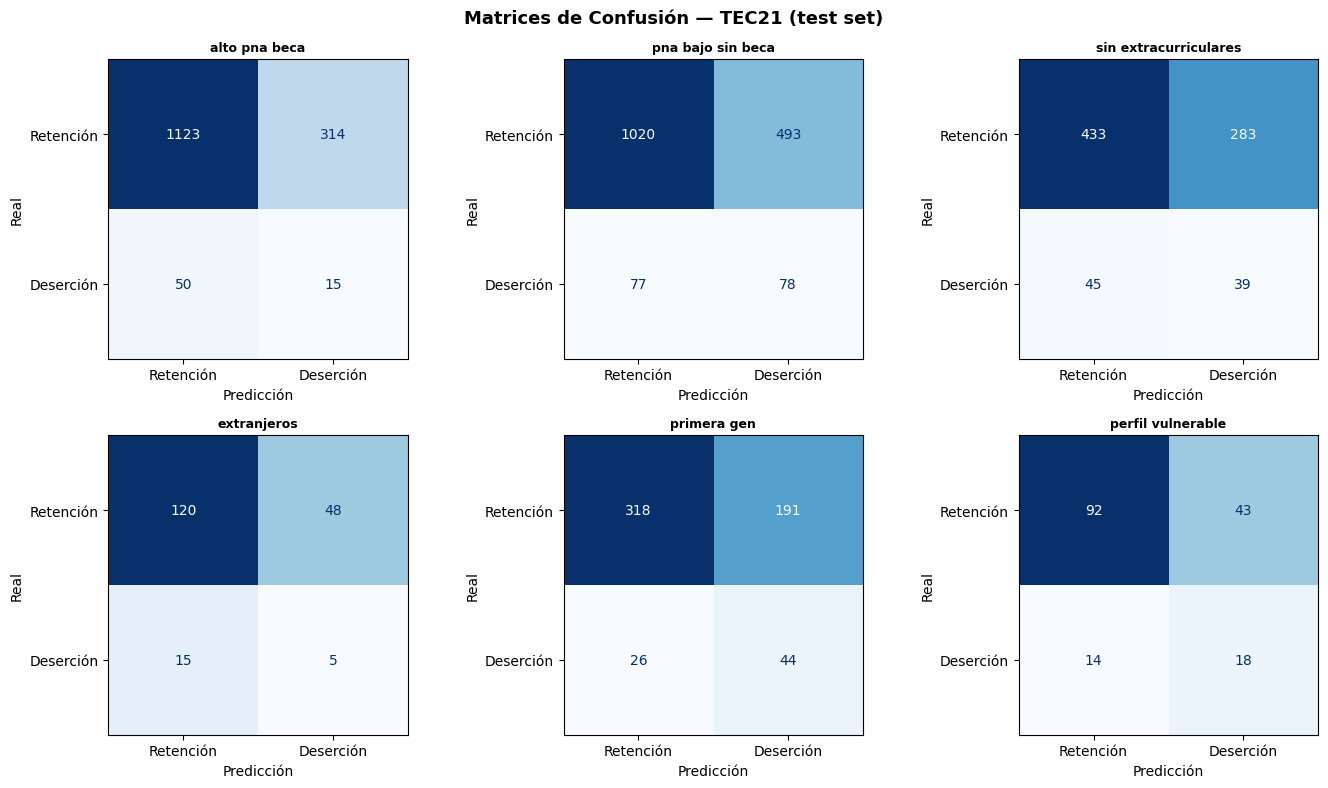

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — TEC21 (test set)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    m = models_tec[cl]
    y_pred = m['rf'].predict(m['X_te'])
    cm = confusion_matrix(m['y_te'], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

---
## 🔍 SHAP — Importancia de Variables (mean |SHAP|)
### Pre-TEC21

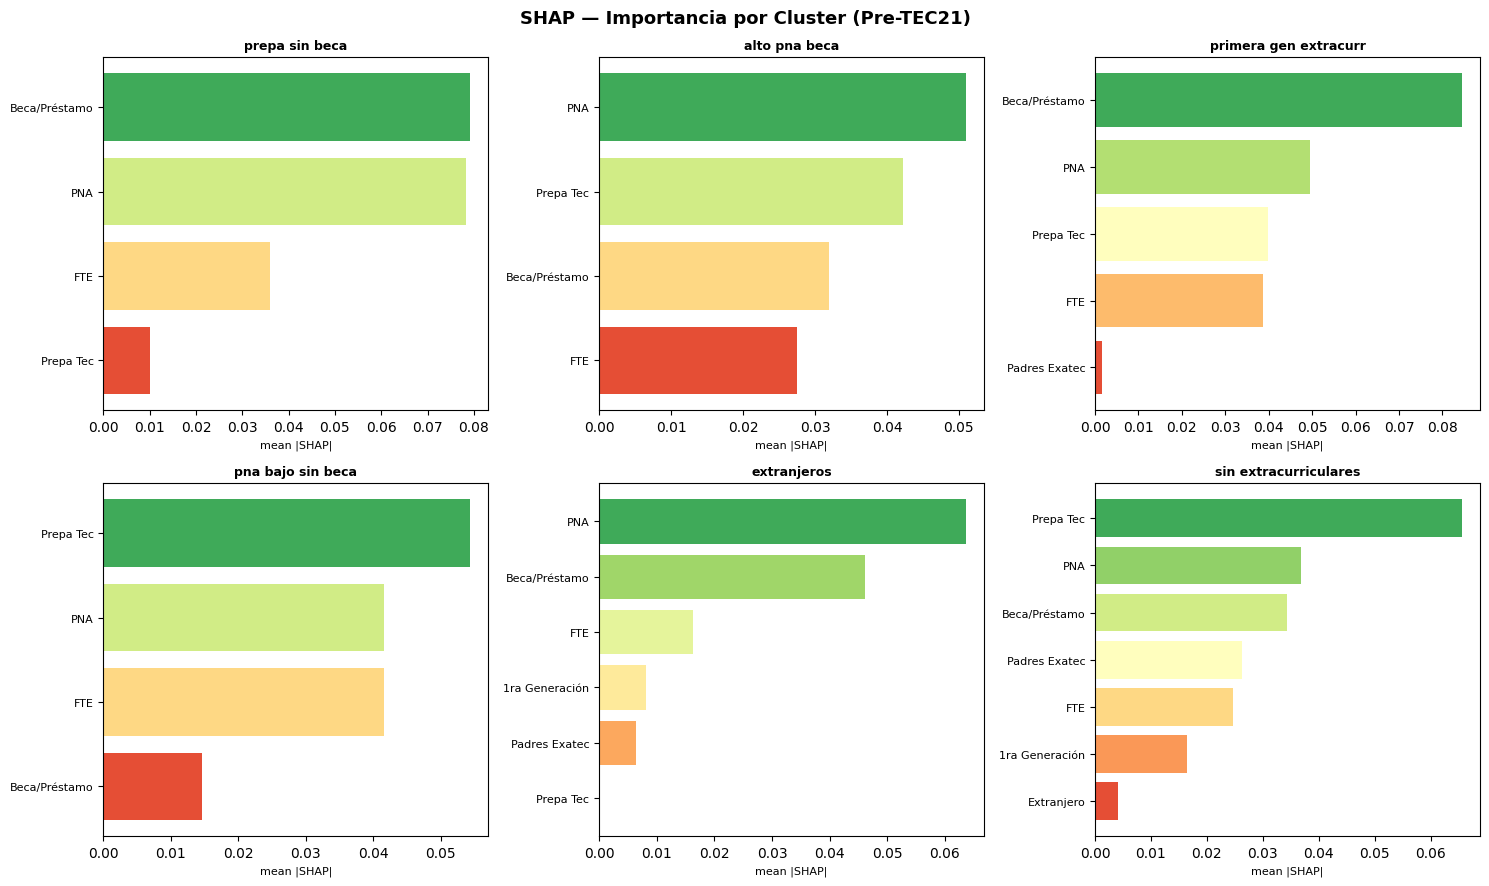

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('SHAP — Importancia por Cluster (Pre-TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    m = models_pre[cl]
    mean_shap  = np.abs(m['shap']).mean(axis=0)
    feat_names = [FEAT_LABELS.get(f, f) for f in m['feats']]
    order      = np.argsort(mean_shap)[::-1]
    vals, labs = mean_shap[order], [feat_names[j] for j in order]
    colors     = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(vals)))

    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout()
plt.show()

### TEC21

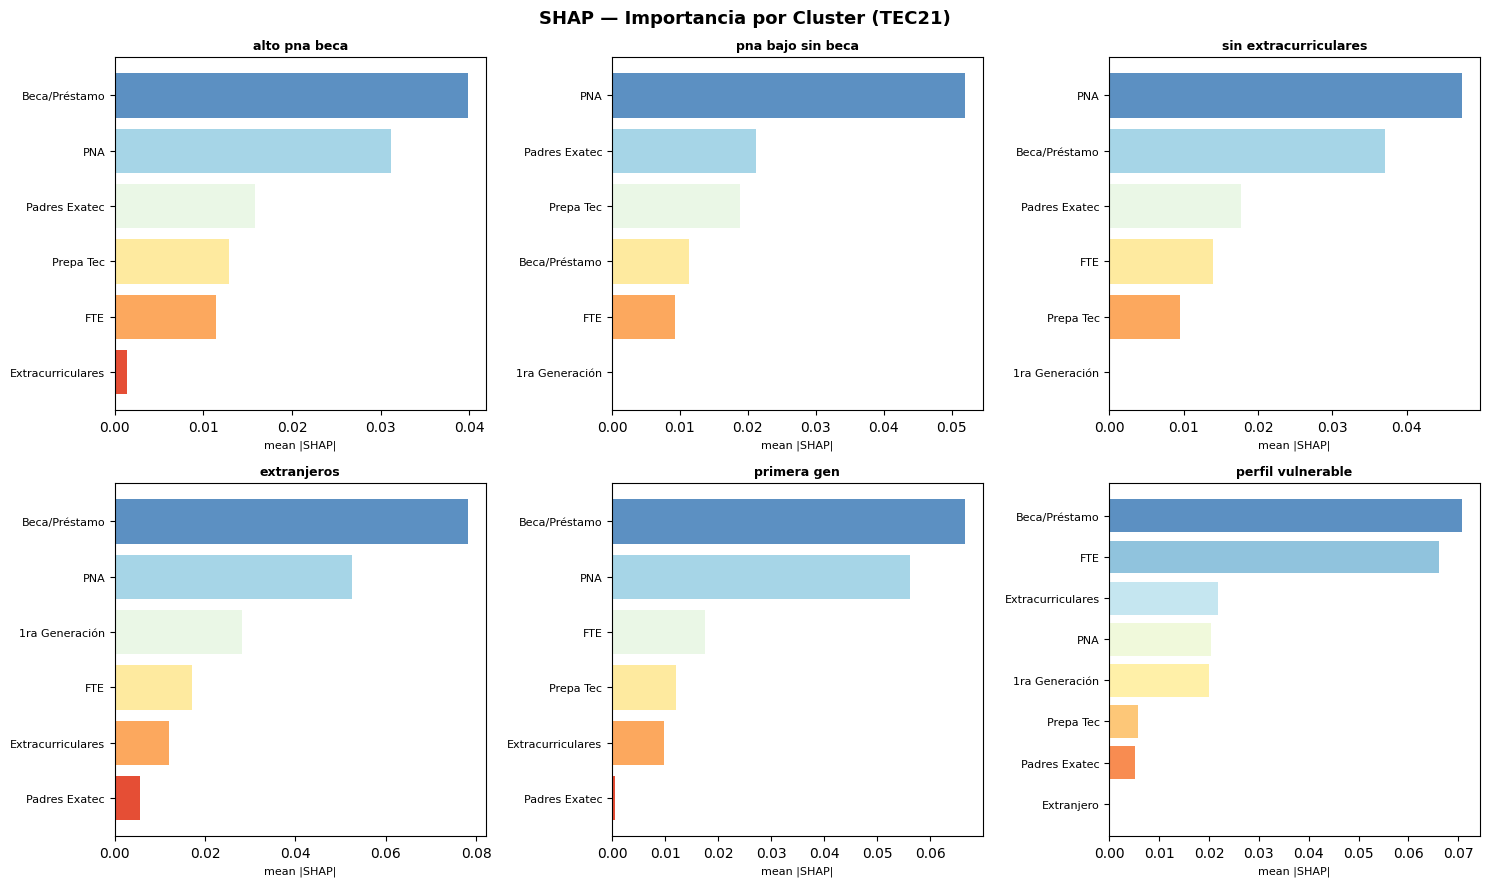

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('SHAP — Importancia por Cluster (TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    m = models_tec[cl]
    mean_shap  = np.abs(m['shap']).mean(axis=0)
    feat_names = [FEAT_LABELS.get(f, f) for f in m['feats']]
    order      = np.argsort(mean_shap)[::-1]
    vals, labs = mean_shap[order], [feat_names[j] for j in order]
    colors     = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(vals)))

    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🐝 SHAP Beeswarm — Dirección del efecto
Cada punto = un estudiante. **Rojo** = valor alto de la variable, **Azul** = bajo.
Posición en X: positivo → empuja hacia **deserción**; negativo → empuja hacia **retención**.
### Pre-TEC21

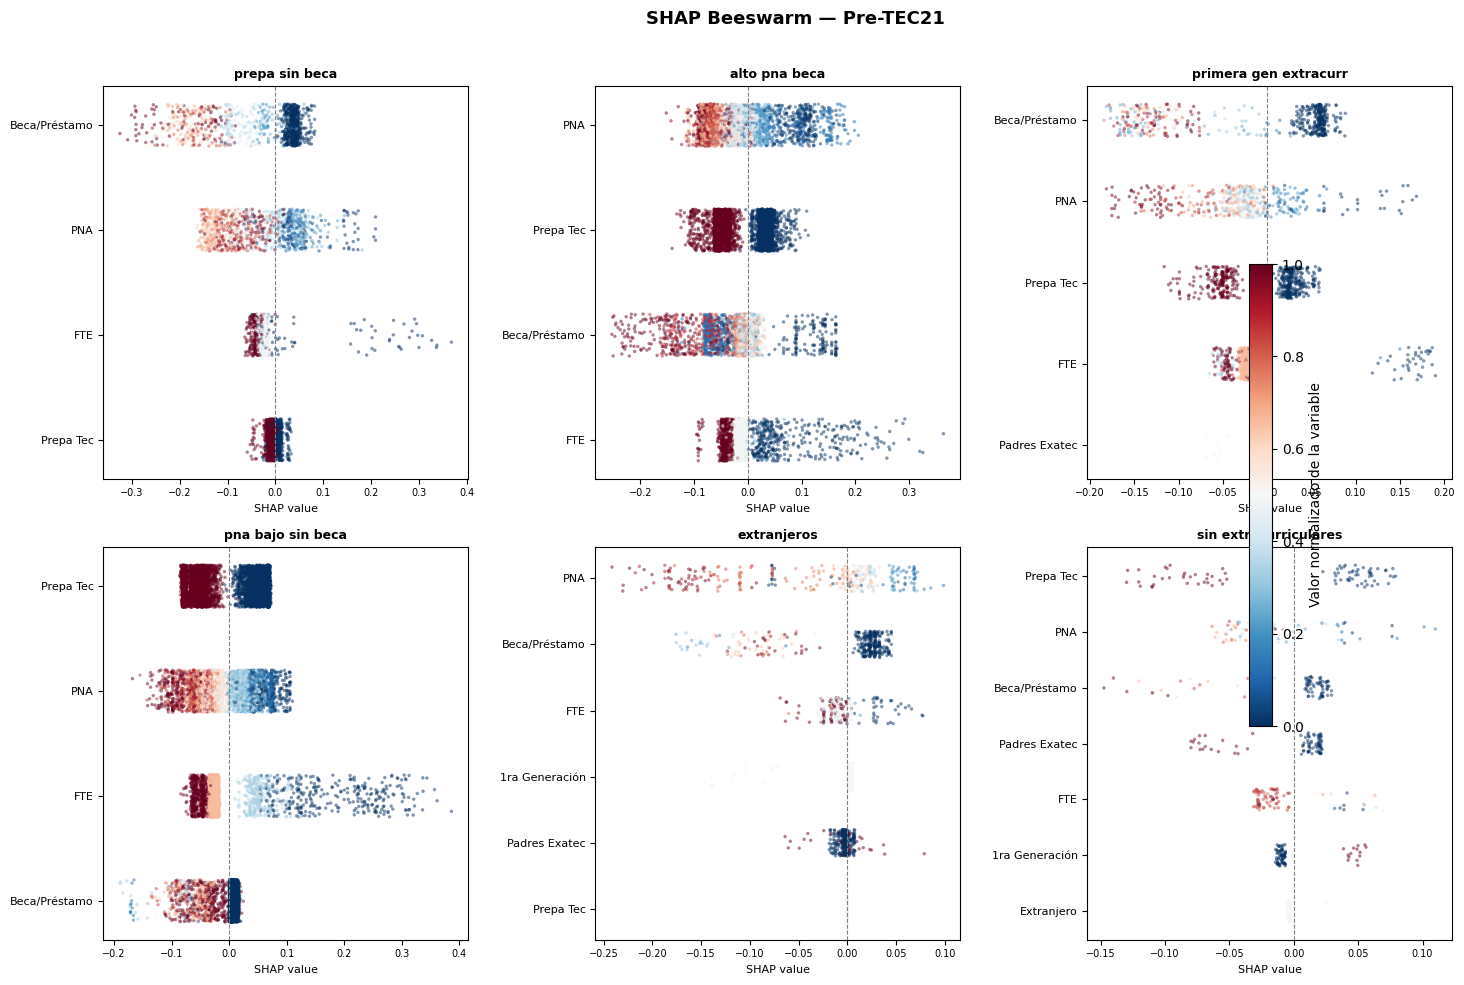

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP Beeswarm — Pre-TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    m = models_pre[cl]
    feat_names = [FEAT_LABELS.get(f, f) for f in m['feats']]
    title = cl.split('_',1)[1].replace('_',' ')
    custom_beeswarm(ax, m['shap'], m['X_te'], feat_names, title)

# Colorbar compartida
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado de la variable', shrink=0.6, pad=0.02)
plt.tight_layout(rect=[0,0,0.92,0.97])
plt.show()

### TEC21

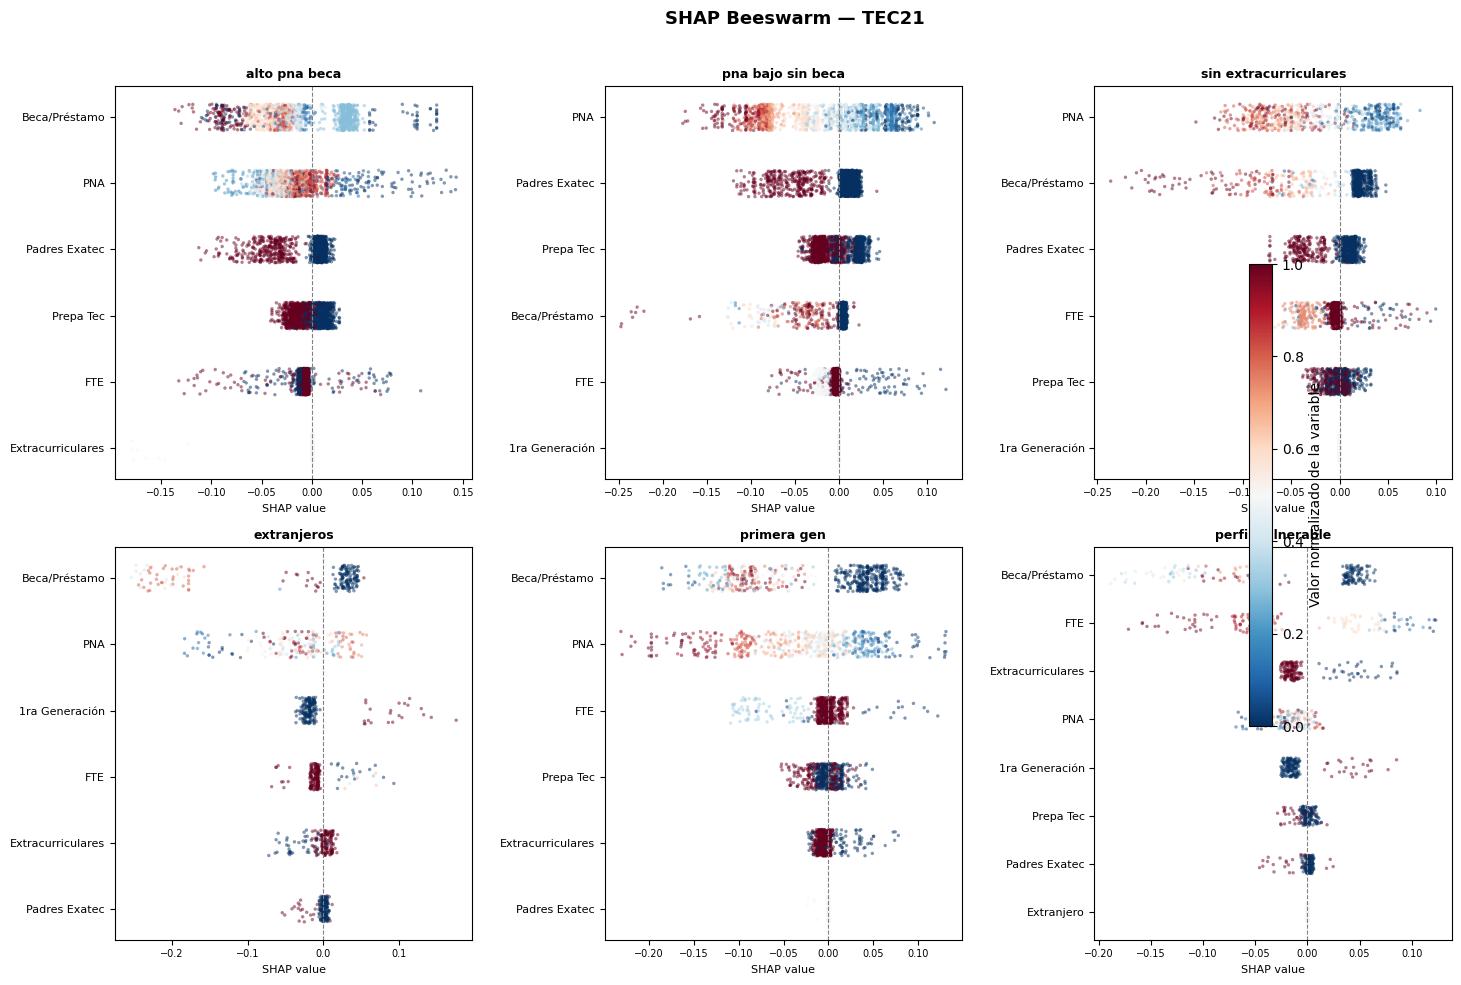

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP Beeswarm — TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    m = models_tec[cl]
    feat_names = [FEAT_LABELS.get(f, f) for f in m['feats']]
    title = cl.split('_',1)[1].replace('_',' ')
    custom_beeswarm(ax, m['shap'], m['X_te'], feat_names, title)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado de la variable', shrink=0.6, pad=0.02)
plt.tight_layout(rect=[0,0,0.92,0.97])
plt.show()

---
## 📋 Resumen consolidado

In [23]:
def fmt_table(mdf, label):
    print("=" * 75)
    print(f"{label} — Métricas Random Forest por Cluster")
    print("=" * 75)
    print(f"{'Cluster':<38} {'n':>7} {'Dropout%':>9} {'Precision':>10} {'Recall':>8} {'F1':>7}")
    print("-" * 75)
    for _, row in mdf.reset_index().iterrows():
        print(f"{row.cluster:<38} {row.n:>7,} {row.dropout_rate:>8.1%} "
              f"{row.precision:>10.3f} {row.recall:>8.3f} {row.f1:>7.3f}")

fmt_table(metrics_pre, 'Pre-TEC21')
print()
fmt_table(metrics_tec, 'TEC21')

Pre-TEC21 — Métricas Random Forest por Cluster
Cluster                                      n  Dropout%  Precision   Recall      F1
---------------------------------------------------------------------------
C0_prepa_sin_beca                        5,695     4.8%      0.082    0.564   0.143
C1_alto_pna_beca                        18,221     6.1%      0.086    0.426   0.144
C2_primera_gen_extracurr                 2,521    10.6%      0.135    0.453   0.208
C3_pna_bajo_sin_beca                    24,505    11.1%      0.140    0.613   0.228
C4_extranjeros                           1,667    14.2%      0.147    0.489   0.227
C5_sin_extracurriculares                   401    20.2%      0.154    0.250   0.190

TEC21 — Métricas Random Forest por Cluster
Cluster                                      n  Dropout%  Precision   Recall      F1
---------------------------------------------------------------------------
C0_alto_pna_beca                         7,510     4.3%      0.046    0.231   0.076

In [24]:
# Variable más influyente por cluster
print()
print("=" * 72)
print("Variable MÁS INFLUYENTE (SHAP) por Cluster")
print("=" * 72)

for label, clusters, models in [("Pre-TEC21", clusters_pre, models_pre),
                                  ("TEC21",     clusters_tec, models_tec)]:
    print(f"\n{label}:")
    for cl in clusters:
        m  = models[cl]
        ms = np.abs(m['shap']).mean(axis=0)
        ti = np.argmax(ms)
        tf = FEAT_LABELS.get(m['feats'][ti], m['feats'][ti])
        tv = ms[ti]
        print(f"  {cl.split('_',1)[1].replace('_',' '):<35} → {tf:<22} (|SHAP|={tv:.4f})")


Variable MÁS INFLUYENTE (SHAP) por Cluster

Pre-TEC21:
  prepa sin beca                      → Beca/Préstamo          (|SHAP|=0.0792)
  alto pna beca                       → PNA                    (|SHAP|=0.0510)
  primera gen extracurr               → Beca/Préstamo          (|SHAP|=0.0844)
  pna bajo sin beca                   → Prepa Tec              (|SHAP|=0.0543)
  extranjeros                         → PNA                    (|SHAP|=0.0636)
  sin extracurriculares               → Prepa Tec              (|SHAP|=0.0656)

TEC21:
  alto pna beca                       → Beca/Préstamo          (|SHAP|=0.0399)
  pna bajo sin beca                   → PNA                    (|SHAP|=0.0520)
  sin extracurriculares               → PNA                    (|SHAP|=0.0475)
  extranjeros                         → Beca/Préstamo          (|SHAP|=0.0782)
  primera gen                         → Beca/Préstamo          (|SHAP|=0.0666)
  perfil vulnerable                   → Beca/Préstamo          (|SH

---
## 🧠 Interpretación de Resultados

### Guía de lectura de métricas

| Precision | Recall | F1   | Significado práctico |
|-----------|--------|------|----------------------|
| Alta      | Alta   | Alto | Modelo muy útil para intervención preventiva |
| Alta      | Baja   | Medio | Pocas alarmas pero se pierden desertores |
| Baja      | Alta   | Medio | Detecta casi todos pero genera muchas falsas alarmas |
| Baja      | Baja   | Bajo | Las variables no distinguen deserción en este cluster |

---

### ¿Por qué F1 puede ser bajo en clusters de bajo riesgo?

Los clusters C0 y C1 tienen tasas de deserción de 4–6%.
Con solo 8 variables de perfil estático, separar ese ~5% de desertores
del 95% que se queda es muy difícil para cualquier modelo.
El F1 bajo en estos clusters **no** indica un mal modelo: indica que
dentro de ese subgrupo las variables disponibles no discriminan bien.
Se necesitarían variables dinámicas (calificaciones, ausencias, etc.).

---

### ¿Cómo usar los SHAP Beeswarms?

- **Eje X positivo (derecha)**: la variable **aumenta** el riesgo de deserción.
- **Eje X negativo (izquierda)**: la variable **reduce** el riesgo.
- **Color rojo** (valor alto de la variable) a la **derecha**: tener mucho de eso es factor de riesgo.
- **Color azul** (valor bajo) a la **derecha**: tener poco de eso es factor de riesgo.

Ejemplo: si en C5 la barra de "Beca/Préstamo" tiene puntos azules a la derecha,
significa que los estudiantes **sin** beca dentro de ese cluster tienen mayor
probabilidad de desertar.

---

### Limitaciones del modelo

1. Solo se usan las 8 variables de clustering; añadir historial académico mejoraría el recall.
2. Clusters pequeños (n < 2,000) presentan mayor varianza en las métricas.
3. `class_weight='balanced'` compensa el desbalance, pero no lo elimina.
4. Los modelos son descriptivos/exploratorios, no predictivos en producción.